In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             accuracy_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

path = r'C:\Users\steff\OneDrive\Desktop\Final Project\Supply Chain Analytics - Project 1'

import os
purchase_orders = pd.read_csv(os.path.join(path, 'purchase_orders.csv'),
                               parse_dates=['order_date','promised_delivery_date','actual_delivery_date'])
inventory =       pd.read_csv(os.path.join(path, 'inventory.csv'))
logistics =       pd.read_csv(os.path.join(path, 'logistics.csv'))
production =      pd.read_csv(os.path.join(path, 'production.csv'), parse_dates=['date'])
sales_forecast =  pd.read_csv(os.path.join(path, 'sales_forecast.csv'), parse_dates=['date'])
suppliers =       pd.read_csv(os.path.join(path, 'suppliers.csv'))

print("All loaded successfully")

All loaded successfully


USE CASE 1: DEMAND FORECASTING

Linear Regression:
  RMSE : 142.33 units
  MAPE : 40.60%

Random Forest Regressor:
  RMSE : 151.42 units
  MAPE : 39.25%

Winner: Linear Regression


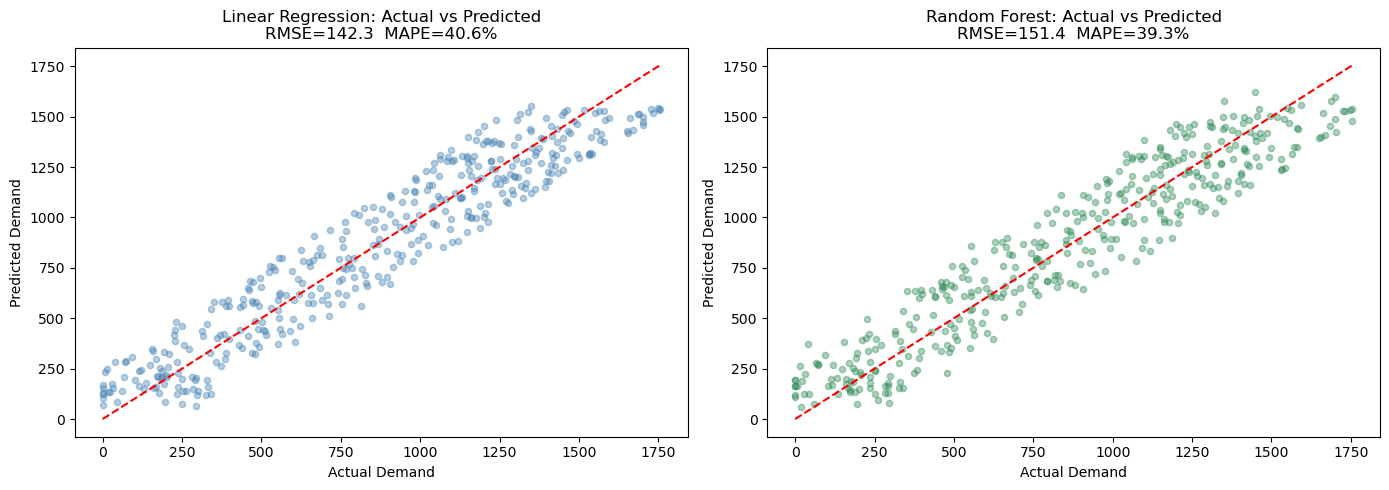

In [3]:
print("=" * 50)
print("USE CASE 1: DEMAND FORECASTING")
print("=" * 50)

# Prepare features
df_forecast = sales_forecast.copy()
df_forecast['month']   = df_forecast['date'].dt.month
df_forecast['quarter'] = df_forecast['date'].dt.quarter
df_forecast['year']    = df_forecast['date'].dt.year

le_sku_fc = LabelEncoder()
df_forecast['sku_encoded'] = le_sku_fc.fit_transform(df_forecast['sku'])

X_fc = df_forecast[['sku_encoded', 'month', 'quarter', 'year', 'historical_demand']]
y_fc = df_forecast['forecasted_demand']

X_fc_train, X_fc_test, y_fc_train, y_fc_test = train_test_split(
    X_fc, y_fc, test_size=0.2, random_state=42)

# Fit models
lr_fc = LinearRegression()
lr_fc.fit(X_fc_train, y_fc_train)
y_fc_pred_lr = lr_fc.predict(X_fc_test)

rf_fc = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fc.fit(X_fc_train, y_fc_train)
y_fc_pred_rf = rf_fc.predict(X_fc_test)

# Convert to numpy — prevents all index alignment errors
y_fc_test_np   = y_fc_test.to_numpy()
y_fc_pred_lr_np = np.array(y_fc_pred_lr)
y_fc_pred_rf_np = np.array(y_fc_pred_rf)

# RMSE
rmse_lr_fc = np.sqrt(mean_squared_error(y_fc_test_np, y_fc_pred_lr_np))
rmse_rf_fc = np.sqrt(mean_squared_error(y_fc_test_np, y_fc_pred_rf_np))

# Safe MAPE — exclude zero demand rows
mask_fc = y_fc_test_np > 0
mape_lr_fc = mean_absolute_percentage_error(
    y_fc_test_np[mask_fc], y_fc_pred_lr_np[mask_fc]) * 100
mape_rf_fc = mean_absolute_percentage_error(
    y_fc_test_np[mask_fc], y_fc_pred_rf_np[mask_fc]) * 100

print(f"\nLinear Regression:")
print(f"  RMSE : {rmse_lr_fc:.2f} units")
print(f"  MAPE : {mape_lr_fc:.2f}%")

print(f"\nRandom Forest Regressor:")
print(f"  RMSE : {rmse_rf_fc:.2f} units")
print(f"  MAPE : {mape_rf_fc:.2f}%")

print(f"\nWinner: {'Random Forest' if rmse_rf_fc < rmse_lr_fc else 'Linear Regression'}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_fc_test_np, y_fc_pred_lr_np, alpha=0.4, s=20, color='steelblue')
axes[0].plot([y_fc_test_np.min(), y_fc_test_np.max()],
             [y_fc_test_np.min(), y_fc_test_np.max()], 'r--')
axes[0].set_title(f'Linear Regression: Actual vs Predicted\nRMSE={rmse_lr_fc:.1f}  MAPE={mape_lr_fc:.1f}%')
axes[0].set_xlabel('Actual Demand')
axes[0].set_ylabel('Predicted Demand')

axes[1].scatter(y_fc_test_np, y_fc_pred_rf_np, alpha=0.4, s=20, color='seagreen')
axes[1].plot([y_fc_test_np.min(), y_fc_test_np.max()],
             [y_fc_test_np.min(), y_fc_test_np.max()], 'r--')
axes[1].set_title(f'Random Forest: Actual vs Predicted\nRMSE={rmse_rf_fc:.1f}  MAPE={mape_rf_fc:.1f}%')
axes[1].set_xlabel('Actual Demand')
axes[1].set_ylabel('Predicted Demand')

plt.tight_layout()
plt.savefig('demand_forecasting.png', dpi=150)
plt.show()

# Store for summary cell
rmse_lr = rmse_lr_fc
rmse_rf = rmse_rf_fc
mape_lr = mape_lr_fc
mape_rf = mape_rf_fc

USE CASE 3: STOCK-OUT RISK PREDICTION

Random Forest Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00        23
     At Risk       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Risk scores exported to stockout_risk_scores.csv

Risk distribution:
risk_label
Low Risk     106
High Risk     14
Name: count, dtype: int64


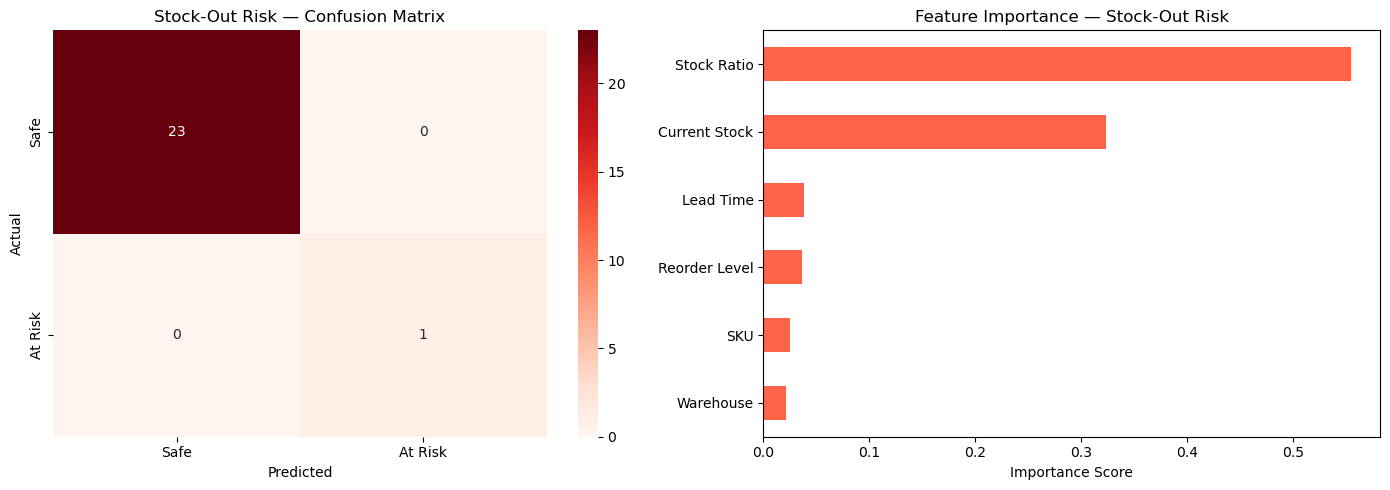

In [4]:
print("=" * 50)
print("USE CASE 3: STOCK-OUT RISK PREDICTION")
print("=" * 50)

# Prepare features
df_inv = inventory.copy()
df_inv['stockout_risk'] = (df_inv['current_stock'] < df_inv['reorder_level']).astype(int)
df_inv['stock_ratio'] = df_inv['current_stock'] / df_inv['reorder_level'].replace(0, 1)
df_inv['shortfall'] = df_inv['reorder_level'] - df_inv['current_stock']

# Add avg lead time per SKU from purchase orders
lead_times = purchase_orders.copy()
lead_times['lead_time'] = (lead_times['actual_delivery_date'] - lead_times['order_date']).dt.days
avg_lead = lead_times.groupby('sku')['lead_time'].mean().reset_index()
avg_lead.columns = ['sku', 'avg_lead_time']

df_inv = df_inv.merge(avg_lead, on='sku', how='left')
df_inv['avg_lead_time'] = df_inv['avg_lead_time'].fillna(df_inv['avg_lead_time'].median())

# Encode
le_wh = LabelEncoder()
le_sk = LabelEncoder()
df_inv['warehouse_encoded'] = le_wh.fit_transform(df_inv['warehouse_id'])
df_inv['sku_encoded'] = le_sk.fit_transform(df_inv['sku'])

# Features and target
X = df_inv[['sku_encoded', 'warehouse_encoded', 'current_stock',
            'reorder_level', 'stock_ratio', 'avg_lead_time']]
y = df_inv['stockout_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_stock = RandomForestClassifier(n_estimators=100, random_state=42)
rf_stock.fit(X_train, y_train)
y_pred_stock = rf_stock.predict(X_test)
y_prob_stock = rf_stock.predict_proba(X_test)[:, 1]
acc_stock = accuracy_score(y_test, y_pred_stock) * 100

print(f"\nRandom Forest Accuracy: {acc_stock:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_stock, target_names=['Safe', 'At Risk']))

# Add risk probability back to inventory for Power BI export
df_inv['stockout_probability'] = rf_stock.predict_proba(
    df_inv[['sku_encoded','warehouse_encoded','current_stock',
            'reorder_level','stock_ratio','avg_lead_time']])[:, 1]
df_inv['risk_label'] = df_inv['stockout_probability'].apply(
    lambda x: 'High Risk' if x > 0.7 else ('Medium Risk' if x > 0.4 else 'Low Risk'))

# Export for Phase 7
export = df_inv[['sku','warehouse_id','current_stock','reorder_level',
                  'stockout_probability','risk_label']]
export.to_csv(os.path.join(path, 'stockout_risk_scores.csv'), index=False)
print(f"\nRisk scores exported to stockout_risk_scores.csv")
print(f"\nRisk distribution:")
print(df_inv['risk_label'].value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(y_test, y_pred_stock)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Safe','At Risk'], yticklabels=['Safe','At Risk'],
            cmap='Reds')
axes[0].set_title('Stock-Out Risk — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

feat_imp2 = pd.Series(rf_stock.feature_importances_,
                      index=['SKU','Warehouse','Current Stock',
                             'Reorder Level','Stock Ratio','Lead Time'])
feat_imp2.sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Feature Importance — Stock-Out Risk')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('stockout_risk.png', dpi=150)
plt.show()

In [7]:
print("=" * 55)
print("PHASE 6 MODEL EVALUATION SUMMARY")
print("=" * 55)
print(f"""
USE CASE 1 — DEMAND FORECASTING
  Linear Regression  RMSE : {rmse_lr:.2f} units  MAPE: {mape_lr:.2f}%
  Random Forest      RMSE : {rmse_rf:.2f} units  MAPE: {mape_rf:.2f}%
  Winner             : {'Random Forest' if rmse_rf < rmse_lr else 'Linear Regression'}

USE CASE 2 — SUPPLIER DELAY PREDICTION
  Logistic Regression Accuracy : {acc_log:.2f}%
  Random Forest Accuracy       : {acc_rf:.2f}%
  Winner                       : {'Random Forest' if acc_rf > acc_log else 'Logistic Regression'}

USE CASE 3 — STOCK-OUT RISK PREDICTION
  Random Forest Accuracy : {acc_stock:.2f}%
  Risk scores exported   : stockout_risk_scores.csv
""")

PHASE 6 MODEL EVALUATION SUMMARY

USE CASE 1 — DEMAND FORECASTING
  Linear Regression  RMSE : 142.33 units  MAPE: 40.60%
  Random Forest      RMSE : 151.42 units  MAPE: 39.25%
  Winner             : Linear Regression

USE CASE 2 — SUPPLIER DELAY PREDICTION
  Logistic Regression Accuracy : 66.88%
  Random Forest Accuracy       : 63.12%
  Winner                       : Logistic Regression

USE CASE 3 — STOCK-OUT RISK PREDICTION
  Random Forest Accuracy : 100.00%
  Risk scores exported   : stockout_risk_scores.csv



USE CASE 2: SUPPLIER DELAY PREDICTION

Logistic Regression Accuracy : 66.88%
Random Forest Accuracy       : 63.12%

Better model: Logistic Regression

Random Forest Classification Report:
              precision    recall  f1-score   support

     On-Time       0.25      0.06      0.09        53
        Late       0.66      0.92      0.77       107

    accuracy                           0.63       160
   macro avg       0.46      0.49      0.43       160
weighted avg       0.53      0.63      0.54       160



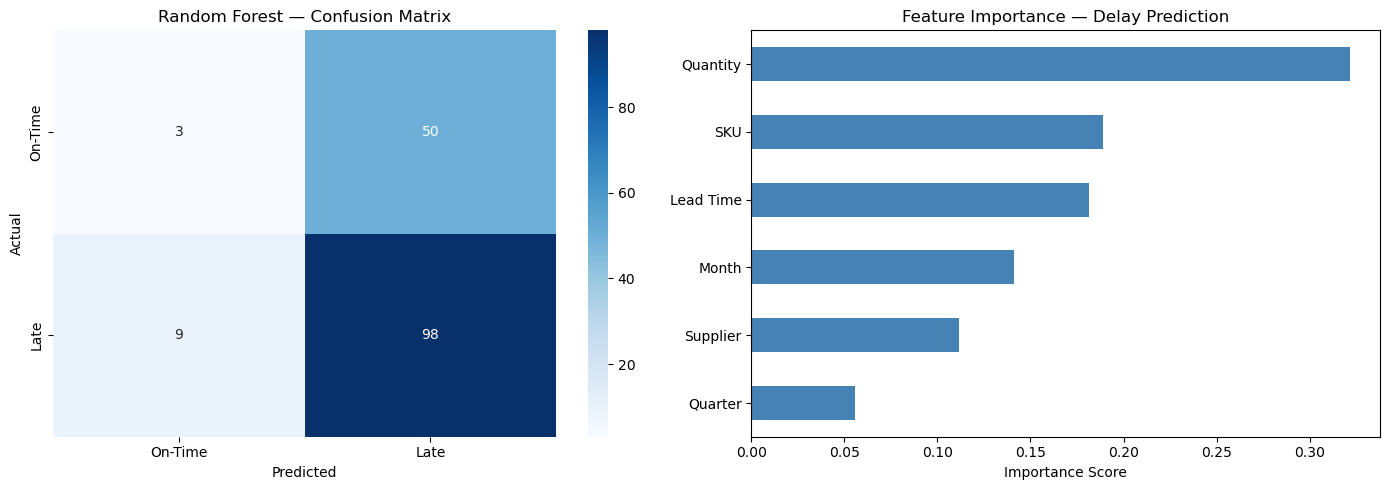

In [6]:
print("=" * 50)
print("USE CASE 2: SUPPLIER DELAY PREDICTION")
print("=" * 50)

# Prepare features
df_delay = purchase_orders.copy()
df_delay['delay_days'] = (df_delay['actual_delivery_date'] - df_delay['promised_delivery_date']).dt.days
df_delay['will_be_late'] = (df_delay['delay_days'] > 0).astype(int)
df_delay['lead_time'] = (df_delay['promised_delivery_date'] - df_delay['order_date']).dt.days
df_delay['order_month'] = df_delay['order_date'].dt.month
df_delay['order_quarter'] = df_delay['order_date'].dt.quarter

# Encode supplier and SKU
le_sup = LabelEncoder()
le_sku2 = LabelEncoder()
df_delay['supplier_encoded'] = le_sup.fit_transform(df_delay['supplier_id'])
df_delay['sku_encoded'] = le_sku2.fit_transform(df_delay['sku'])

# Features and target
X = df_delay[['supplier_encoded', 'sku_encoded', 'quantity', 'lead_time', 'order_month', 'order_quarter']]
y = df_delay['will_be_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1 — Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log) * 100

# Model 2 — Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf_clf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf_clf) * 100

print(f"\nLogistic Regression Accuracy : {acc_log:.2f}%")
print(f"Random Forest Accuracy       : {acc_rf:.2f}%")
print(f"\nBetter model: {'Random Forest' if acc_rf > acc_log else 'Logistic Regression'}")

print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_clf, target_names=['On-Time', 'Late']))

# Feature importance
feat_imp = pd.Series(rf_clf.feature_importances_,
                     index=['Supplier', 'SKU', 'Quantity', 'Lead Time', 'Month', 'Quarter'])
feat_imp = feat_imp.sort_values(ascending=True)

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_rf_clf)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=['On-Time','Late'], yticklabels=['On-Time','Late'],
            cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — Delay Prediction')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('delay_prediction.png', dpi=150)
plt.show()    